# 01-EDA Campaign Funnel Classification

Goal: understand the shape of the dataset, find signals that should be useful
for funnel labelling, and surface anything weird before we touch a model.

Dataset: `campaigns_unlabeled.csv` — one row per campaign per active month.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

df = pd.read_csv("campaigns_unlabeled.csv")
print(df.shape)
df.head()


(4546, 20)


,campaign_id,customer_id,platform,campaign_name,objective,bidding_strategy,optimization_event,ad_format,audience_type,daily_budget_usd,month,impressions,clicks,conversions,spend_usd,ctr,cpm_usd,cpc_usd,conversion_rate,roas
0,CMP-00001,CUST-0001,google_ads,Product launch New users Aug,Website traffic,Maximize clicks,Conversions,Responsive search,remarketing,127.37,6,119170,2465,220,3221.17,0.020687,27.03,1.3068,0.089549,1.94
1,CMP-00001,CUST-0001,google_ads,Product launch New users Aug,Website traffic,Maximize clicks,Conversions,Responsive search,remarketing,127.37,7,93238,1830,116,2180.84,0.019628,23.39,1.1917,0.063731,1.91
2,CMP-00001,CUST-0001,google_ads,Product launch New users Aug,Website traffic,Maximize clicks,Conversions,Responsive search,remarketing,127.37,8,87314,1726,115,2258.81,0.019771,25.87,1.3087,0.066790,2.59
3,CMP-00001,CUST-0001,google_ads,Product launch New users Aug,Website traffic,Maximize clicks,Conversions,Responsive search,remarketing,127.37,9,95962,1851,140,2356.83,0.019289,24.56,1.2733,0.076077,2.11
4,CMP-00002,CUST-0001,google_ads,Cold audience A/B,Brand awareness and reach,CPM,Impressions,Video - Non-skippable,broad,641.07,4,83947,1202,2,418.06,0.014326,4.98,0.3478,0.002239,NaN


## 1. Basic shape & dtypes

In [2]:
print("rows:", len(df))
print("unique campaigns:", df.campaign_id.nunique())
print("unique customers:", df.customer_id.nunique())
print("platforms:", df.platform.unique())
print("months covered:", sorted(df.month.unique()))
print()
print(df.dtypes)


rows: 4546
unique campaigns: 637
unique customers: 120
platforms: ['google_ads' 'tiktok_ads' 'meta_ads' 'linkedin_ads']
months covered: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

campaign_id            object
customer_id            object
platform               object
campaign_name          object
objective              object
bidding_strategy       object
optimization_event     object
ad_format              object
audience_type          object
daily_budget_usd      float64
month                   int64
impressions             int64
clicks                  int64
conversions             int64
spend_usd             float64
ctr                   float64
cpm_usd               float64
cpc_usd               float64
conversion_rate       float64
roas                  float64
dtype: object


months/campaign — describe:
count    637.000000
mean       7.136578
std        3.104348
min        2.000000
25%        4.000000
50%        7.000000
75%       10.000000
max       12.000000
Name: month, dtype: float64


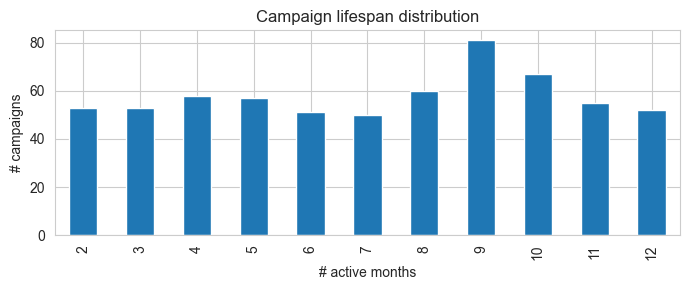

In [3]:
# rows per campaign = active months
months_per_campaign = df.groupby("campaign_id").month.nunique()
print("months/campaign — describe:")
print(months_per_campaign.describe())

fig, ax = plt.subplots(figsize=(7, 3))
months_per_campaign.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("# active months")
ax.set_ylabel("# campaigns")
ax.set_title("Campaign lifespan distribution")
plt.tight_layout(); plt.show()


## 2. Missingness

In [ ]:
#Return on Ad Spend 
miss = df.isna().mean().sort_values(ascending=False)
print(miss[miss > 0])
print()
# Important！！！！ roas null = conversion value not tracked. This itself is a funnel signal.
print("roas null rate by audience_type:")
print(df.assign(roas_null=df.roas.isna()).groupby("audience_type").roas_null.mean().sort_values())


roas    0.493841
dtype: float64

roas null rate by audience_type:
audience_type
remarketing        0.274368
lookalike_small    0.293139
customer_list      0.351585
in_market          0.395745
affinity           0.603306
lookalike_large    0.734513
broad              0.810901
Name: roas_null, dtype: float64


## 3. Platform & customer distribution

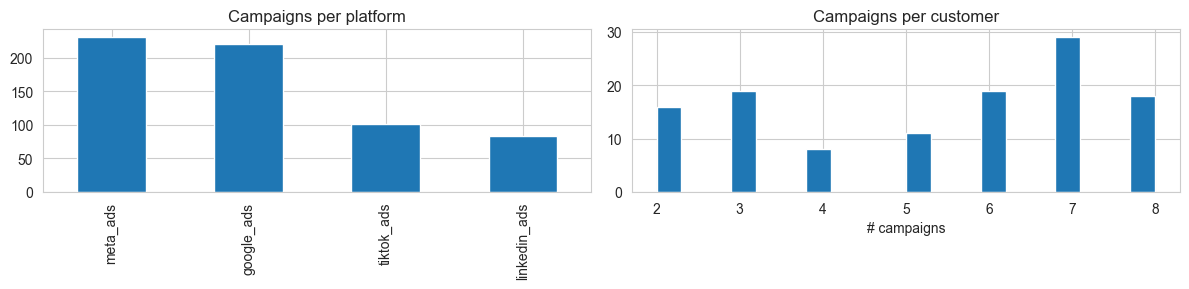

campaigns/customer — describe:
count    120.000000
mean       5.308333
std        2.077474
min        2.000000
25%        3.000000
50%        6.000000
75%        7.000000
max        8.000000
dtype: float64


In [5]:
# campaign-level (not row-level) view
campaign_config = df.drop_duplicates("campaign_id")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
campaign_config.platform.value_counts().plot(kind="bar", ax=axes[0], title="Campaigns per platform")
campaigns_per_customer = campaign_config.groupby("customer_id").size()
axes[1].hist(campaigns_per_customer, bins=20)
axes[1].set_title("Campaigns per customer"); axes[1].set_xlabel("# campaigns")
plt.tight_layout(); plt.show()

print("campaigns/customer — describe:")
print(campaigns_per_customer.describe())


## 4. Numerical distributions (log scale for long tails)

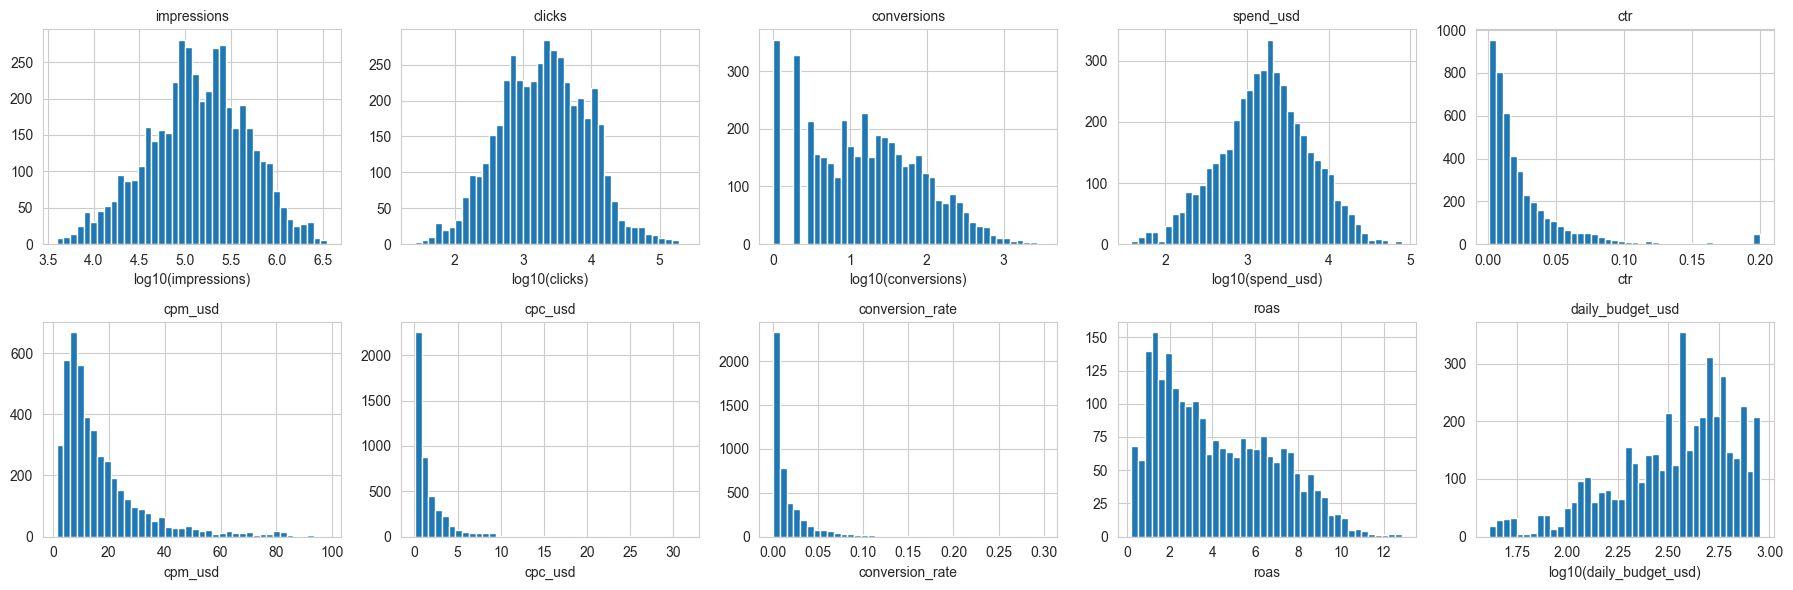

In [6]:
metrics = ["impressions", "clicks", "conversions", "spend_usd",
           "ctr", "cpm_usd", "cpc_usd", "conversion_rate", "roas", "daily_budget_usd"]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, col in zip(axes.flat, metrics):
    s = df[col].dropna()
    if col in ("impressions", "clicks", "conversions", "spend_usd", "daily_budget_usd"):
        s = np.log10(s.replace(0, np.nan).dropna())
        ax.set_xlabel(f"log10({col})")
    else:
        ax.set_xlabel(col)
    ax.hist(s, bins=40)
    ax.set_title(col, fontsize=10)
plt.tight_layout(); plt.show()


## 5. Funnel-relevant exploration

Top-funnel campaigns typically:
- broader audiences (broad/affinity/lookalike)
- awareness/reach objectives, video formats
- high CPM, low CTR, low conversion rate, no ROAS tracked

Bottom-funnel campaigns typically:
- warm audiences (remarketing/customer_list)
- conversion/sales objectives, lead/DPA formats
- higher CTR, higher conversion rate, ROAS tracked


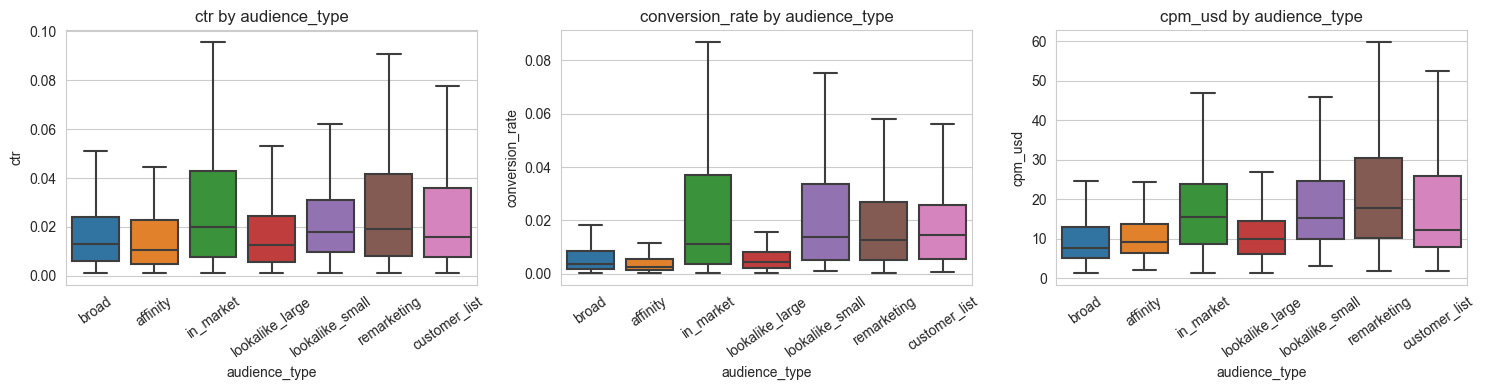

In [7]:
# audience_type vs key rates
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order = ["broad", "affinity", "in_market", "lookalike_large", "lookalike_small", "remarketing", "customer_list"]
for ax, col in zip(axes, ["ctr", "conversion_rate", "cpm_usd"]):
    sns.boxplot(data=df, x="audience_type", y=col, order=order, ax=ax, showfliers=False)
    ax.tick_params(axis="x", rotation=35)
    ax.set_title(f"{col} by audience_type")
plt.tight_layout(); plt.show()


In [8]:
# objective and optimization_event are platform-specific text fields. Check uniques.
print("objectives:")
print(df.objective.value_counts().head(20))
print()
print("optimization_events:")
print(df.optimization_event.value_counts().head(20))
print()
print("ad_formats:")
print(df.ad_format.value_counts().head(20))


objectives:
Leads                          376
Brand awareness and reach      371
Sales                          358
Website traffic                344
Sales - Conversions            279
Sales - Catalog sales          277
Lead generation                261
Awareness - Brand awareness    234
Traffic                        230
Unset                          223
Website conversions            218
Awareness - Reach              201
Video views                    190
App promotion                  167
Reach                          134
Brand awareness                127
Engagement                     124
Awareness - Video views        100
Product sales                   92
TikTok interactions             87
Name: objective, dtype: int64

optimization_events:
Impressions           706
Conversions           583
Clicks                457
Reach                 376
Video views           282
Conversion value      190
Lead                  180
Purchase              177
Add to cart           152
Le

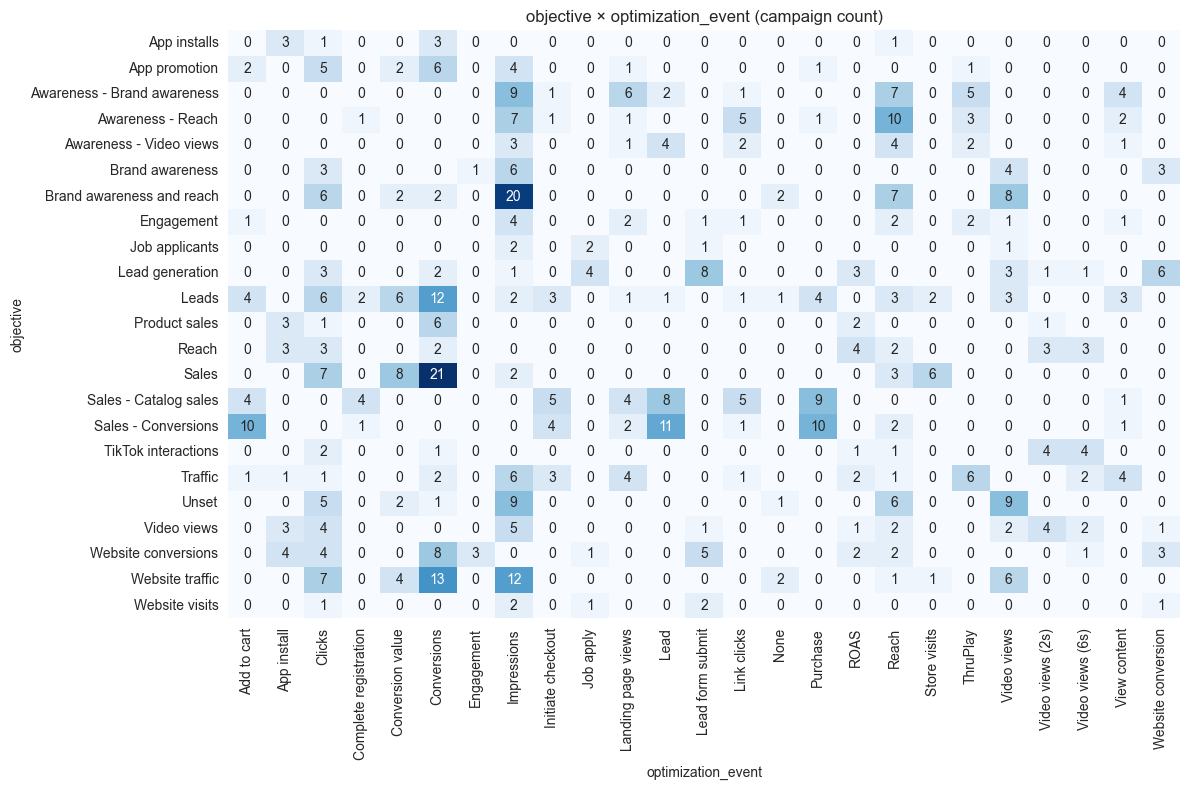

In [9]:
# Heatmap: objective x optimization_event (campaign-level)
ct = pd.crosstab(campaign_config.objective, campaign_config.optimization_event)
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(ct, cmap="Blues", annot=True, fmt="d", cbar=False, ax=ax)
ax.set_title("objective × optimization_event (campaign count)")
plt.tight_layout(); plt.show()


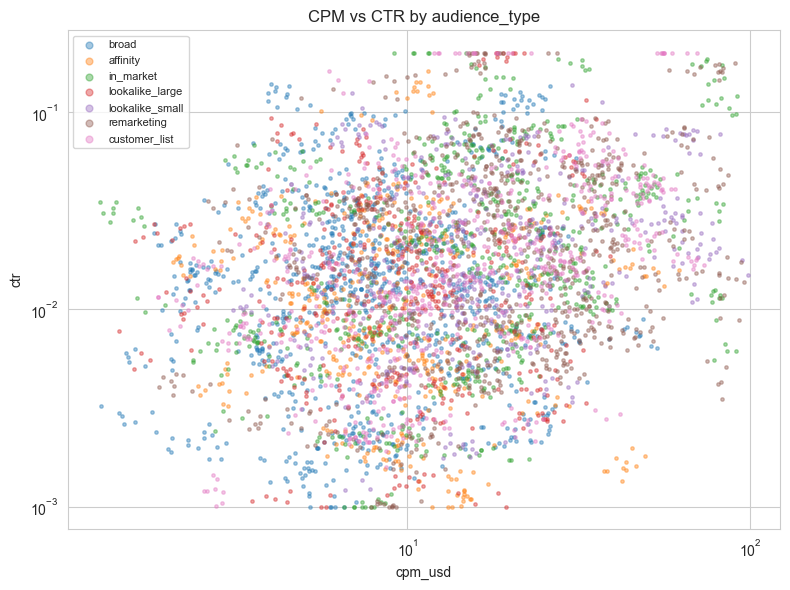

In [10]:
# CPM vs CTR coloured by audience_type — should separate top/bottom
fig, ax = plt.subplots(figsize=(8, 6))
for aud in order:
    sub = df[df.audience_type == aud]
    ax.scatter(sub.cpm_usd, sub.ctr, s=6, alpha=0.4, label=aud)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("cpm_usd"); ax.set_ylabel("ctr")
ax.set_title("CPM vs CTR by audience_type")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()


## 6. Campaign name — text exploration

In [11]:
STOPWORDS = {"the","a","an","and","or","for","of","to","in","on","with","new","2024","2025",
             "jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec",
             "q1","q2","q3","q4","campaign","ad","ads"}

def tokens(name):
    return [t for t in re.findall(r"[a-z]+", str(name).lower()) if t not in STOPWORDS and len(t) > 2]

all_tokens = [t for n in campaign_config.campaign_name for t in tokens(n)]
top = Counter(all_tokens).most_common(40)
print("Top 40 tokens in campaign names:")
for t, c in top: print(f"  {t:25s} {c}")


Top 40 tokens in campaign names:
  funnel                    109
  tof                       33
  black                     33
  friday                    33
  spring                    31
  sale                      31
  lower                     30
  awareness                 30
  product                   28
  launch                    28
  cyber                     28
  monday                    28
  top                       27
  upper                     27
  copy                      26
  holiday                   26
  bottom                    25
  test                      24
  apac                      23
  newsletter                23
  webinar                   23
  back                      21
  school                    21
  summer                    21
  demo                      21
  enterprise                21
  conversion                20
  women                     20
  millennials               19
  app                       19
  suite                     19
  con

In [12]:
# Funnel-keyword hit rate
TOP_KW = {"awareness","reach","prospecting","launch","brand","video","tof","upper","views","awareness"}
BOT_KW = {"retarget","retargeting","remarketing","conversion","conversions","purchase","sales",
          "lead","leads","bof","bottom","branded","cart","checkout"}

def name_signal(name):
    toks = set(tokens(name))
    has_top = bool(toks & TOP_KW)
    has_bot = bool(toks & BOT_KW)
    if has_top and not has_bot: return "top"
    if has_bot and not has_top: return "bottom"
    if has_top and has_bot: return "conflict"
    return "none"

campaign_config["name_signal"] = campaign_config.campaign_name.apply(name_signal)
print(campaign_config.name_signal.value_counts(normalize=True).round(3))


none        0.630
top         0.198
bottom      0.168
conflict    0.005
Name: name_signal, dtype: float64


/var/folders/_g/lw72tct53cz9qjmtbn8jkr8m0000gn/T/ipykernel_60530/1730526513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  campaign_config["name_signal"] = campaign_config.campaign_name.apply(name_signal)


## 7. Customer-level aggregation (prep for Part 2)

In [13]:
cust_agg = df.groupby("customer_id").agg(
    n_campaigns=("campaign_id", "nunique"),
    n_platforms=("platform", "nunique"),
    total_spend=("spend_usd", "sum"),
    total_impressions=("impressions", "sum"),
).sort_values("total_spend", ascending=False)
print(cust_agg.head())
print()
print(cust_agg.describe())


             n_campaigns  n_platforms  total_spend  total_impressions
customer_id                                                          
CUST-0030              8            1    666963.75           52352132
CUST-0033              6            1    635344.56           35990559
CUST-0053              8            2    590630.06           27687234
CUST-0013              8            2    531687.13           39386006
CUST-0034              8            2    436061.42           22989820

       n_campaigns  n_platforms    total_spend  total_impressions
count   120.000000   120.000000     120.000000       1.200000e+02
mean      5.308333     1.516667  132414.166083       1.036917e+07
std       2.077474     0.660829  122825.117899       8.725359e+06
min       2.000000     1.000000    4048.960000       7.605000e+05
25%       3.000000     1.000000   52546.527500       3.812621e+06
50%       6.000000     1.000000  108120.720000       8.412150e+06
75%       7.000000     2.000000  172345.772500 

## Good INFO to stage_A after EDA Check 

- ~637 campaigns, 120 customers — small dataset → linear / boosted models, not deep nets.
- Multiple rows per campaign (one per active month). Need to aggregate to campaign level before modelling.
- Strong heuristic signals available: `audience_type`, `objective`, `optimization_event`, `ad_format`, `campaign_name` keywords.
- `roas` null vs not-null is itself a funnel signal — keep as a boolean feature.
- Numeric metrics are long-tailed → log-transform for linear models.
- Same customer's campaigns share naming style → must split by `customer_id` in CV to avoid leakage.
